# Task 1 [2 points]


1. Download and upload data from the category Sports and Outdoors:
https://cseweb.ucsd.edu/ jmcauley/datasets/amazon_v2/. Process the reviews into a pd.DataFrame
with columns [’user_id’, ’asin’, ’rating’, ’timestamp’]. Take care of the memory
usage of your implementation.
2. What is the 5-core version?
3. Provide a basic data analysis for the full variant and the 5-core version:
- (a) number of interactions for each item (sort the counts for readability),
- (b) the distribution of users’ number of interactions,
- (c) calculate the sparsity (how many of the possible user-item pairs are present in the data),
- (d) check for duplicates of contradictory data,
- (e) other plots that you find interesting.
4. Consider the following train-test split procedures. What are their advantages and disadvan-
tages? Think of user and item representation, biases, leakage, and suitability for the ranking
task.
- Randomly select 20% of all interactions.
- Randomly select 20% of users and put all their interactions in the test set.
- Select 20% of interactions for each user at random.
- Select the most recent 20% of interactions for each user.
- Select a fixed number of the most recent interactions for each user to obtain around 20%
of the data.
- Select the most recent 20% of all interactions.
5. Use the 5-core variant. Perform a train-test split by selecting the 2 most recent items for each
user for testing.
6. Think about how you can transform the data into boolean feedback.
You can obtain a point for the implementation and a point for the comments and answers

In [1]:
from pathlib import Path
import gc
import pandas as pd

REVIEWS_JSON = Path("data/Sports_and_Outdoors.json")

required_cols = ["reviewerID", "asin", "overall", "unixReviewTime"]
chunk_size = 100000
chunks = []

for i, chunk in enumerate(pd.read_json(REVIEWS_JSON, lines=True, chunksize=chunk_size), start=1):
    chunk = chunk[required_cols].rename(
        columns={
            "reviewerID": "user_id",
            "overall": "rating",
            "unixReviewTime": "timestamp",
        }
    )

    chunk["rating"] = chunk["rating"].astype("float32")
    chunk["timestamp"] = chunk["timestamp"].astype("int64")
    chunks.append(chunk)

    if i % 10 == 0:
        print(f"Processed {i:,} chunks...")

reviews_df = pd.concat(chunks, ignore_index=True)
reviews_df["user_id"] = reviews_df["user_id"].astype("category")
reviews_df["asin"] = reviews_df["asin"].astype("category")

# release temporary chunk objects
del chunks
try:
    del chunk
except NameError:
    pass
gc.collect()

mem_mb = reviews_df.memory_usage(deep=True).sum() / (1024**2)
print(f"\nDataFrame memory usage: {mem_mb:.2f} MB")

print(reviews_df.head())
print("\nColumns:", list(reviews_df.columns))
print("\nDtypes:")
print(reviews_df.dtypes)
print(f"\nRows: {len(reviews_df):,}")
print(f"Unique users: {reviews_df['user_id'].nunique():,}")
print(f"Unique items: {reviews_df['asin'].nunique():,}")

Processed 10 chunks...
Processed 20 chunks...
Processed 30 chunks...
Processed 40 chunks...
Processed 50 chunks...
Processed 60 chunks...
Processed 70 chunks...
Processed 80 chunks...
Processed 90 chunks...
Processed 100 chunks...
Processed 110 chunks...
Processed 120 chunks...
Processed 130 chunks...

DataFrame memory usage: 992.81 MB
          user_id        asin  rating   timestamp
0  A23K73OVXJ04EG  0000031895     5.0  1391212800
1  A2681T699HV6H1  0000031895     4.0  1384905600
2  A374PA18DCGS5Y  0000031895     1.0  1477008000
3  A14PVW2N5YBWSA  0000031895     5.0  1476748800
4  A2KWBC44QI2567  0000031895     1.0  1476662400

Columns: ['user_id', 'asin', 'rating', 'timestamp']

Dtypes:
user_id      category
asin         category
rating        float32
timestamp       int64
dtype: object

Rows: 12,980,837
Unique users: 6,703,391
Unique items: 957,764


5-core is version filtered version to include only users and items that have at least 5 interactions


===== FULL =====

(a) Top 20 items by interactions:
asin
B00V6JAEDC    10226
B0017IHRNM     9472
B00G7H793G     8801
B0013092CS     8592
B00FO9ZRYQ     8591
B004X55L9I     8058
B0010O748Q     7974
B0017IFSIS     7886
B00NPLSZF8     7754
B00X77YTS2     7664
B00FFADO8A     7516
B018L2WM86     7351
B00177BQJE     7040
7245456313     6695
B00A6TBITM     6501
B00SGB60YK     6315
B00Q46Z7A2     6314
B0146A4SWA     6245
B001N3MKT2     5999
B0076R6MN4     5984
dtype: int64

(b) User interactions distribution summary:
count    6.703391e+06
mean     1.936458e+00
std      2.683295e+00
min      1.000000e+00
50%      1.000000e+00
90%      4.000000e+00
95%      5.000000e+00
99%      1.200000e+01
max      4.330000e+02
dtype: float64

(c) Sparsity stats:
users=6,703,391, items=957,764
observed user-item pairs=12,601,954
possible user-item pairs=6,420,266,577,724
density=0.00000196 (0.000196%)
sparsity=0.99999804 (99.999804%)

(d) Duplicate/contradiction checks:
exact duplicates (same user,item,rating

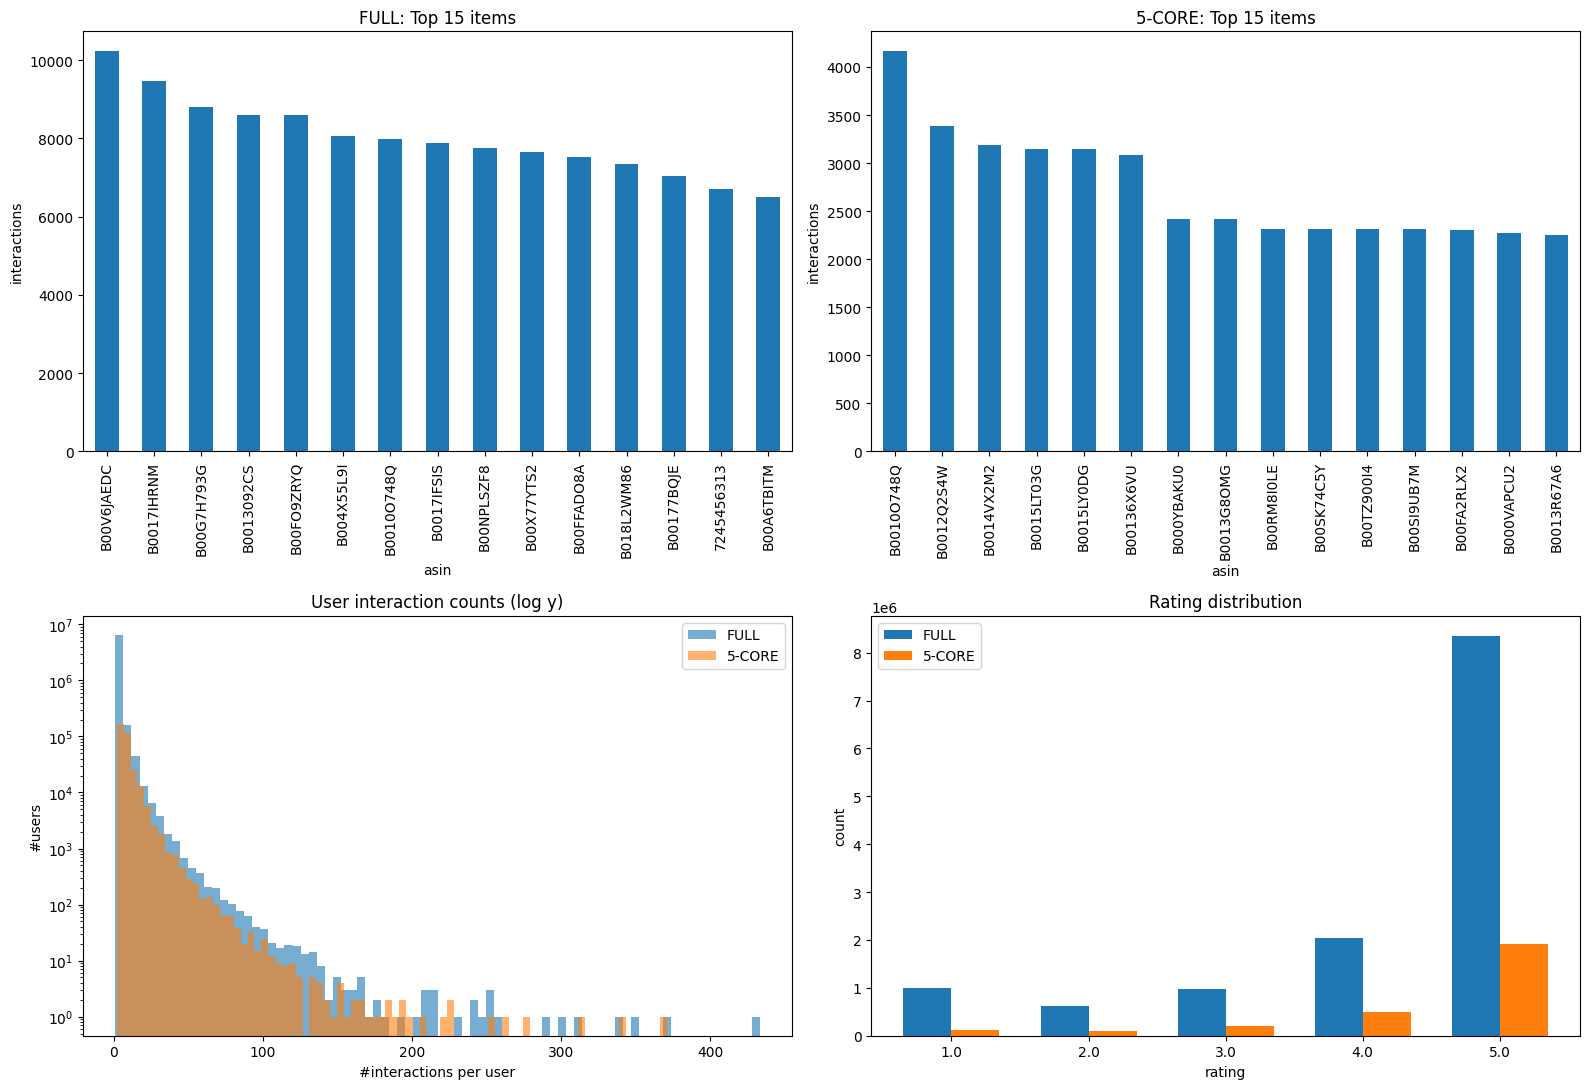

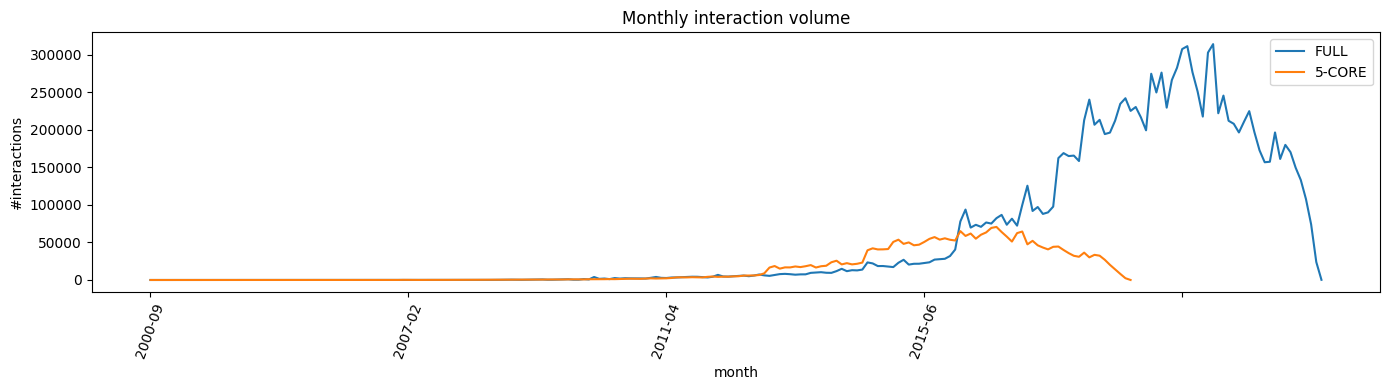

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_reviews(path):
    df = pd.read_json(
        path,
        lines=True,
        dtype={
            "reviewerID": "string",
            "asin": "string",
            "overall": "float32",
            "unixReviewTime": "int64",
        },
    )[["reviewerID", "asin", "overall", "unixReviewTime"]].rename(
        columns={
            "reviewerID": "user_id",
            "overall": "rating",
            "unixReviewTime": "timestamp",
        }
    )
    df["user_id"] = df["user_id"].astype("category")
    df["asin"] = df["asin"].astype("category")
    return df


def analyze(df, name):
    print(f"\n===== {name} =====")

    item_counts = df.groupby("asin", observed=True).size().sort_values(ascending=False)
    print("\n(a) Top 20 items by interactions:")
    print(item_counts.head(20))

    user_counts = df.groupby("user_id", observed=True).size()
    print("\n(b) User interactions distribution summary:")
    print(user_counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    n_users = df["user_id"].nunique()
    n_items = df["asin"].nunique()
    observed_pairs = df[["user_id", "asin"]].drop_duplicates().shape[0]
    possible_pairs = n_users * n_items
    density = observed_pairs / possible_pairs if possible_pairs else 0.0
    sparsity = 1.0 - density

    print("\n(c) Sparsity stats:")
    print(f"users={n_users:,}, items={n_items:,}")
    print(f"observed user-item pairs={observed_pairs:,}")
    print(f"possible user-item pairs={possible_pairs:,}")
    print(f"density={density:.8f} ({density*100:.6f}%)")
    print(f"sparsity={sparsity:.8f} ({sparsity*100:.6f}%)")

    exact_dups = int(df.duplicated(subset=["user_id", "asin", "rating", "timestamp"]).sum())
    contradictory_same_time = int(
        df.groupby(["user_id", "asin", "timestamp"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )
    changed_rating_over_time = int(
        df.groupby(["user_id", "asin"], observed=True)["rating"]
        .nunique()
        .gt(1)
        .sum()
    )

    print("\n(d) Duplicate/contradiction checks:")
    print(f"exact duplicates (same user,item,rating,timestamp): {exact_dups:,}")
    print(f"contradictory same-timestamp ratings: {contradictory_same_time:,}")
    print(f"same user-item with different ratings over time: {changed_rating_over_time:,}")

    monthly_counts = (
        pd.to_datetime(df["timestamp"], unit="s")
        .dt.to_period("M")
        .astype(str)
        .value_counts()
        .sort_index()
    )

    return {
        "item_counts": item_counts,
        "user_counts": user_counts,
        "rating_counts": df["rating"].value_counts().sort_index(),
        "monthly_counts": monthly_counts,
    }


full_path = Path("data/Sports_and_Outdoors.json")
core_path = Path("data/Sports_and_Outdoors_5.json")

if not full_path.exists() or not core_path.exists():
    raise FileNotFoundError("Run cell 3 first to download/unpack data.")

full_df = reviews_df if "reviews_df" in globals() else load_reviews(full_path)
core_df = load_reviews(core_path)

full_stats = analyze(full_df, "FULL")
core_stats = analyze(core_df, "5-CORE")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

full_stats["item_counts"].head(15).plot(kind="bar", ax=axes[0, 0], title="FULL: Top 15 items")
axes[0, 0].set_xlabel("asin")
axes[0, 0].set_ylabel("interactions")

core_stats["item_counts"].head(15).plot(kind="bar", ax=axes[0, 1], title="5-CORE: Top 15 items")
axes[0, 1].set_xlabel("asin")
axes[0, 1].set_ylabel("interactions")

axes[1, 0].hist(full_stats["user_counts"], bins=80, alpha=0.6, label="FULL")
axes[1, 0].hist(core_stats["user_counts"], bins=80, alpha=0.6, label="5-CORE")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("User interaction counts (log y)")
axes[1, 0].set_xlabel("#interactions per user")
axes[1, 0].set_ylabel("#users")
axes[1, 0].legend()

ratings = sorted(set(full_stats["rating_counts"].index).union(set(core_stats["rating_counts"].index)))
full_rc = [full_stats["rating_counts"].get(r, 0) for r in ratings]
core_rc = [core_stats["rating_counts"].get(r, 0) for r in ratings]

x = np.arange(len(ratings))
w = 0.35
axes[1, 1].bar(x - w / 2, full_rc, width=w, label="FULL")
axes[1, 1].bar(x + w / 2, core_rc, width=w, label="5-CORE")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([str(r) for r in ratings])
axes[1, 1].set_title("Rating distribution")
axes[1, 1].set_xlabel("rating")
axes[1, 1].set_ylabel("count")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
full_stats["monthly_counts"].plot(label="FULL")
core_stats["monthly_counts"].plot(label="5-CORE")
plt.title("Monthly interaction volume")
plt.xlabel("month")
plt.ylabel("#interactions")
plt.xticks(rotation=70)
plt.legend()
plt.tight_layout()
plt.show()